# (연구) importance of data (HST old example) 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

In [1]:
# hide
import rpy2 
%load_ext rpy2.ipython

### Define functions 

In [2]:
%%R 
hst1d<-function(f,tau,b=sd(f)*0.01,prob=c(1/3,1/3,1/3)) # prob=c(l,c,r)
{
  lprob<-prob[1]
  cprob<-prob[2]
  rprob<-prob[3]
  len<-length(f)
  hstresult<-rep(0,len*tau); dim(hstresult)<-c(len,tau)
  hlen<-round(len/2)
  oldf<-f
  f<-c(f[hlen:1],f,f[len:(len-hlen+1)])
  
  ls<-landshape(f)
  f_before<-f
  f_after<-f*0
  L<-length(f)

  for(i in 1:tau)
  {
    minindex<-which(ls=="minimum")
    maxindex<-which(ls=="maximum")
    incindex<-which(ls=="increasing")
    decindex<-which(ls=="decreasing")
    flatindex<-which(ls=="flat")
    epsilon<-runif(1)*b
    f_after[minindex]<-f_before[minindex]+epsilon+epsilon*lprob+epsilon*rprob
    f_after[maxindex]<-f_before[maxindex]+epsilon*cprob
    f_after[incindex]<-f_before[incindex]+epsilon*(cprob+rprob)+epsilon*(lprob)
    f_after[decindex]<-f_before[decindex]+epsilon*(cprob+lprob)+epsilon*(rprob)
    f_after[flatindex]<-f_before[flatindex]+epsilon*cprob+epsilon*rprob*0.5+epsilon*lprob*0.5
    ls<-landshape(f_after)
    f_before<-f_after
    hstresult[,i]<-f_after[(hlen+1):(L-hlen)]
  }
  cbind(oldf,hstresult)
}

landshape<-function(f)
{
  len<-length(f)
  ls<-f*0
  ls[c(1,len)]<-"flat"
  for(i in 2:(len-1))
  {
    if((f[i]>f[i-1])&(f[i]<f[i+1])) ls[i]<-"increasing"
    else if((f[i]<f[i-1])&(f[i]>f[i+1])) ls[i]<-"decreasing"
    else if(mean(c(f[i-1],f[i+1]))<f[i]) ls[i]<-"maximum"
    else if(mean(c(f[i-1],f[i+1]))>f[i]) ls[i]<-"minimum"
    else ls[i]<-"flat"
  }
  ls
}

dist<-function(hstrslt)
{
  n<-dim(hstrslt)[1]
  distancematrix<-rep(0,n*n)
  dim(distancematrix)<-c(n,n)
  for(i in 1:n)
  {
    for(j in 1:n)
    {
      distancematrix[i,j]<-sum((hstrslt[i,]-hstrslt[j,])^2)
    }
  }
  distancematrix
}

impt<-function(distancematrix,radius)
{
  n<-dim(distancematrix)[1]
  imp<-rep(0,n)
  for(i in 1:n)
  {
    imp[i]<-1/(sum((distancematrix[i,]<radius)*1)/n)
  }
  imp
}

`-` `hst1d()`: hst를 구현한 함수

`-` `landshape()`: 땅의 모양(?)을 구하는 함수 / hst1d를 구현할때 필요함 
    
`-` `dist()`: hst의 결과를 바탕으로 snow distance를 구하는 함수

`-` `impt()`: importance를 계산하는 함수

### Data

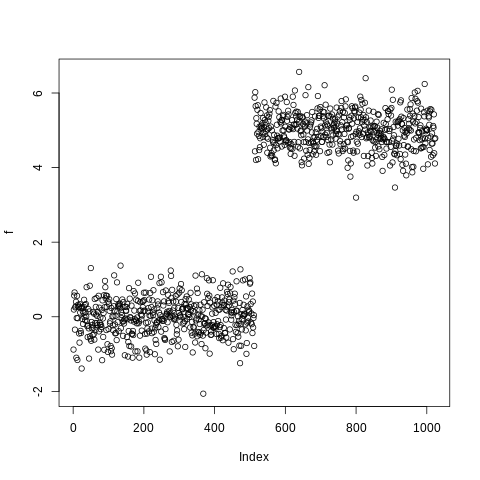

In [3]:
%%R 
## define the function 
f<-c(rnorm(512,0,0.5),rnorm(512,5,0.5))
plot(f)

`-` 그냥 평범한 예제자료 

### HST

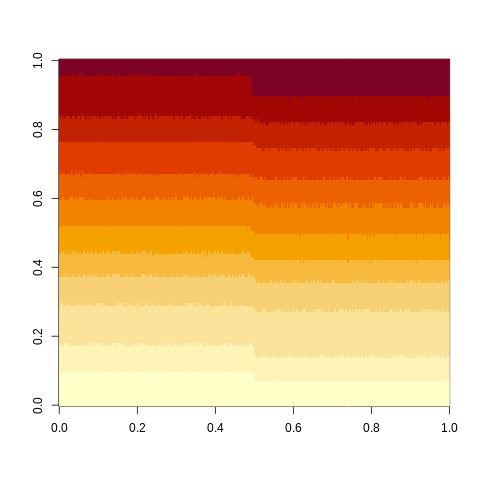

In [4]:
%%R 
hstrlst_once<-hst1d(f,tau=120,b=3)
image(hstrlst_once)

`-` HST를 한번 수행한 결과를 그려봄. 

### HST $\times$ 10 

`-` hst를 10번정도 적용시킨후에 평균을 구함. 
- 원래 좀더 많은 시뮬레이션을 했으면 좀 더 결과가 안정적이었겠지만 시간관계상 10번정도만 구했음
- 사실 어차피 결과는 비슷해 10번이 아니라 1번만 해도 무방했음 


In [5]:
%%R 
hstrslt<-hst1d(f,tau=240,b=1)
for(i in 1:9) hstrslt<-hstrslt+hst1d(f,tau=240,b=1) 
hstrslt<- hstrslt/10

### PCA 

`-` 시각화를 위한 PCA 수행

In [6]:
%%R
PCrslt<-princomp(hstrslt)

### Distance $\to$ Importance

`-` hst의 결과를 바탕으로 importance를 구함. 

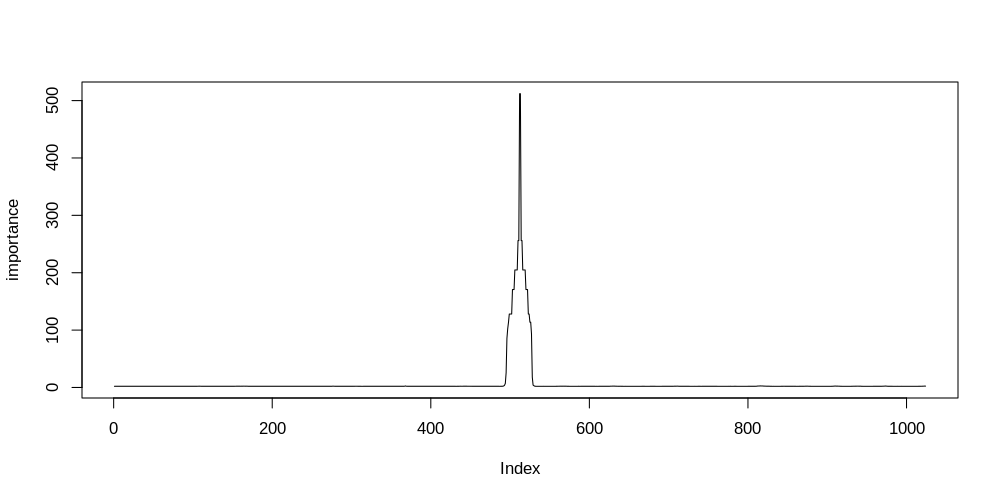

In [7]:
%%R -w 1000 -h 500 -r 100
distancematrix<-dist(hstrslt)
importance<-impt(distancematrix,radius=30)
plot(importance,type='l')

`-` 적절한 반지름을 선택해야함 (현재는 30으로 설정함) 
- 반지름을 너무 크게 설정하면 모든 점들이 포함됨. 
- 반지름을 너무 작게 설정하면 하나도 포함되지 않음. 

### Visualization

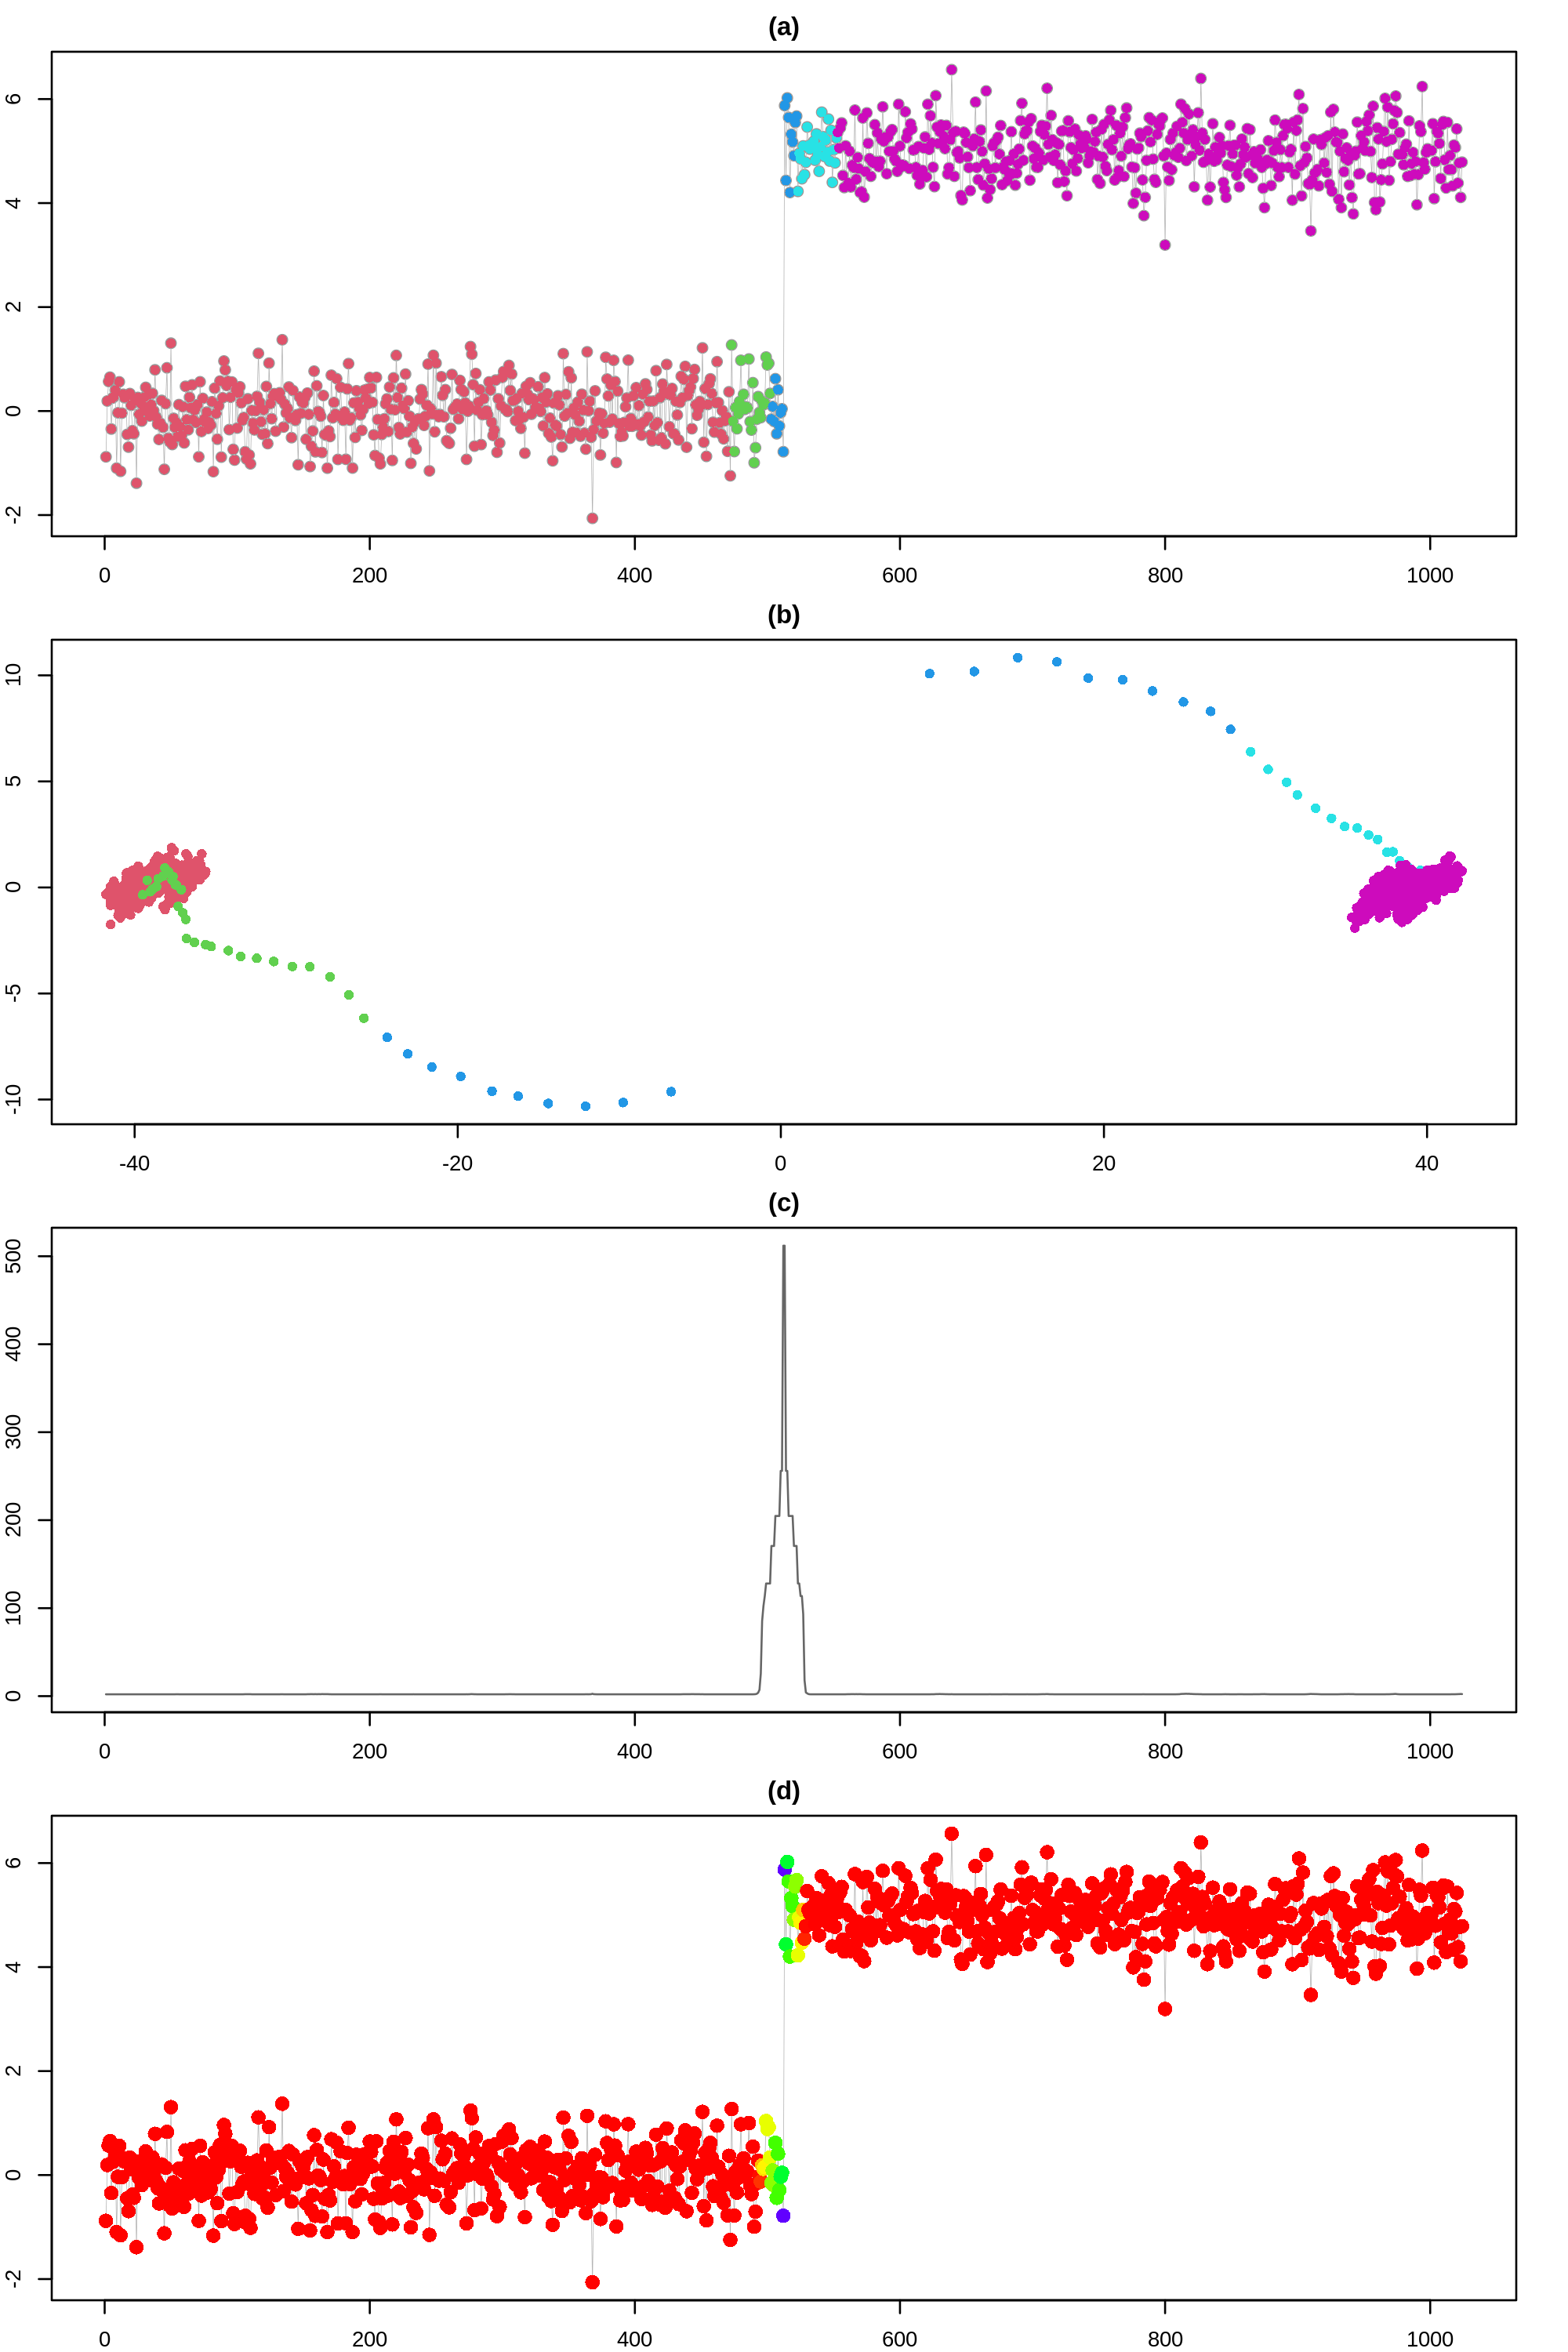

In [21]:
%%R -w 2000 -h 3000 -r 250
rb<-rainbow(700)
## temp variable for ploting 
xrange1<-1:472
xrange2<-473:502
xrange3<-503:522
xrange4<-523:552
xrange5<-553:1024
### snow_ex3_fig1
par(mfrow=c(4,1))
par(mar=c(2,2,2,2))
plot(f,col="gray60",main="(a)",xlab="",ylab="")
lines(f,lwd=0.3,col="gray70")
points(xrange1,f[xrange1],col=2,pch=16)
points(xrange2,f[xrange2],col=3,pch=16)
points(xrange3,f[xrange3],col=4,pch=16)
points(xrange4,f[xrange4],col=5,pch=16)
points(xrange5,f[xrange5],col=6,pch=16)
### snow_ex3_fig2
plot(PCrslt$scores[,1], PCrslt$scores[,2],col="gray60",cex=0.7,main="(b)",xlab="",ylab="")
points(PCrslt$scores[xrange1,1], PCrslt$scores[xrange1,2],col=2,pch=16)
points(PCrslt$scores[xrange2,1], PCrslt$scores[xrange2,2],col=3,pch=16)
points(PCrslt$scores[xrange3,1], PCrslt$scores[xrange3,2],col=4,pch=16)
points(PCrslt$scores[xrange4,1], PCrslt$scores[xrange4,2],col=5,pch=16)
points(PCrslt$scores[xrange5,1], PCrslt$scores[xrange5,2],col=6,pch=16)
### snow_ex3_fig3
plot(importance,cex=0.7,main="(c)",xlab="",ylab="",type='l',col="gray40")

### snow_ex3_fig4
plot(f,col="gray60",cex=0.1,main="(d)",xlab="",ylab="")
lines(f,lwd=0.3,col="gray70")
points(f,col=rb[importance],cex=1.5,pch=16)
points(f,col=rb[importance],cex=1.5,pch=16)
par(mfrow=c(1,1))